# 📊 Session 6: Practical Data Preprocessing & Pipeline Engineering
### Case Study: Bank Marketing Dataset (UCI ID 222)

Welcome to **Session 6**! In this session, we put into practice the theoretical concepts introduced in **Session 5** (`Pre Processing.md`, `Data Cleaning.md`, `Data Transformation.md`, and `Correlation Analysis.md`).

Throughout this notebook, we emphasize a crucial pedagogical comparison:
> **The Pandas Way vs. The Scikit-Learn Way**  
> When to use Pandas for exploration, and why Scikit-Learn's `Pipeline` and `ColumnTransformer` are mandatory for leak-free production modeling.

---

### 📚 Table of Contents
1. [Setup & Environment](#sec-1)
2. [Data Ingestion & Inspection (`ucimlrepo`)](#sec-2)
3. [Data Cleaning: Missingness Diagnosis (MCAR, MAR, MNAR)](#sec-3)
4. [The `duration` Dilemma: Identifying Target Leakage](#sec-4)
5. [Feature Engineering: Binary Indicators & Principled Binning](#sec-5)
6. [Correlation Analysis: Pearson Correlation Coefficient ($r$)](#sec-6)
7. [Data Transformation & Scaling: How to Diagnose What Needs Scaling](#sec-7)
8. [Categorical Encoding: `pd.get_dummies()` vs. `OneHotEncoder`](#sec-8)
9. [Zero-Leakage Train-Test Splitting](#sec-9)
10. [The Unified Scikit-Learn Preprocessing Pipeline](#sec-10)
11. [Handling Imbalanced Data (7.5 : 1): The Accuracy Paradox](#sec-11)
12. [All-in-One Benchmark Matrix: Imputation & Scaling Side-by-Side](#sec-12)
13. [Interactive Preprocessing & Model Sandbox Widget](#sec-13)
14. [The Masterclass: Doing Preprocessing "Real Proper"](#sec-14)


<a id="sec-1"></a>
## 1. Setup & Environment
Run this cell first to initialize data manipulation, statistical, machine learning, and visualization libraries.


In [1]:
# Setup & Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn & Imbalanced-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, Checkbox, IntSlider, Output, VBox, HBox
from IPython.display import display, HTML

# UCI ML Repo
from ucimlrepo import fetch_ucirepo

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

print("Setup complete! Libraries imported successfully.")


Setup complete! Libraries imported successfully.


<a id="sec-2"></a>
## 2. Data Ingestion & Inspection (`ucimlrepo`)

### The Dataset
The **Bank Marketing Dataset** (UCI ID 222) contains results of direct marketing campaigns (phone calls) by a Portuguese banking institution seeking subscriptions for a long-term deposit.

We fetch the dataset directly into pandas DataFrames:


In [2]:
# Fetch dataset via ucimlrepo
bank_marketing = fetch_ucirepo(id=222)

# Extract features and targets
X_raw = bank_marketing.data.features.copy()
y_raw = bank_marketing.data.targets.copy()

print(f"Dataset Shape: {X_raw.shape[0]:,} rows, {X_raw.shape[1]} features")
print(f"Target Shape: {y_raw.shape[0]:,} rows, {y_raw.shape[1]} target column")


Dataset Shape: 45,211 rows, 16 features
Target Shape: 45,211 rows, 1 target column


In [3]:
# Display sample data and feature metadata
display(X_raw.head())
print("\n--- Variable Information ---")
display(bank_marketing.variables[['name', 'role', 'type', 'description', 'missing_values']])


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN



--- Variable Information ---


,name,role,type,description,missing_values
0,age,Feature,Integer,None,no
1,job,Feature,Categorical,"type of job (categorical: 'admin.','blue-colla...",no
2,marital,Feature,Categorical,"marital status (categorical: 'divorced','marri...",no
3,education,Feature,Categorical,"(categorical: 'basic.4y','basic.6y','basic.9y'...",no
4,default,Feature,Binary,has credit in default?,no
5,balance,Feature,Integer,average yearly balance,no
6,housing,Feature,Binary,has housing loan?,no
7,loan,Feature,Binary,has personal loan?,no
8,contact,Feature,Categorical,contact communication type (categorical: 'cell...,yes
9,day_of_week,Feature,Date,last contact day of the week,no


<a id="sec-3"></a>
## 3. Data Cleaning: Missingness Diagnosis (MCAR, MAR, MNAR)

As taught in **Session 5 (Data Cleaning)**, cleaning data is about ensuring **Accuracy, Completeness, Consistency, and Uniformity**.

Let's inspect the missing values in our features:


In [4]:
# Check missing values
missing = X_raw.isnull().sum()
missing_pct = (missing / len(X_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(2)})
missing_df[missing_df['Missing Count'] > 0]


,Missing Count,Percentage (%)
job,288,0.64
education,1857,4.11
contact,13020,28.80
poutcome,36959,81.75


### ⚠️ Why `X.dropna()` is Disastrous Here!
Let's see what happens if someone blindly runs `dropna()`:


In [5]:
rows_before = len(X_raw)
rows_after = len(X_raw.dropna())
print(f"Rows before dropna(): {rows_before:,}")
print(f"Rows after dropna():  {rows_after:,}")
print(f"Data Lost: {((rows_before - rows_after) / rows_before) * 100:.1f}% of entire dataset!")


Rows before dropna(): 45,211
Rows after dropna():  7,842
Data Lost: 82.7% of entire dataset!


### Understanding the Structural Missingness in `poutcome` (MNAR)
Why is `poutcome` 81.75% missing?
Let's check `previous` (the number of contacts performed before this campaign):


In [6]:
# Check poutcome missingness conditioned on previous contacts
pct_null_when_no_prior = (X_raw[X_raw['previous'] == 0]['poutcome'].isnull()).mean() * 100
print(f"When previous == 0 (never contacted before), poutcome is null in: {pct_null_when_no_prior:.1f}% of cases!")

# When previous > 0, what are the values?
print("\nWhen previous > 0, distribution of poutcome:")
display(X_raw[X_raw['previous'] > 0]['poutcome'].value_counts(dropna=False))


When previous == 0 (never contacted before), poutcome is null in: 100.0% of cases!

When previous > 0, distribution of poutcome:


poutcome
failure    4901
other      1840
success    1511
NaN           5
Name: count, dtype: int64

The nulls in `poutcome` are **structurally missing** (Missing Not At Random) because a client never contacted before cannot have an outcome from a past campaign!
- **Pandas Way:** `df['poutcome'] = df['poutcome'].fillna('not_contacted')`
- **Sklearn Way:** `SimpleImputer(strategy='constant', fill_value='not_contacted')`

### Sentinel Values: `pdays = -1`
`pdays` indicates the days elapsed since the client was previously contacted. If never contacted, it is marked as `-1`.
Treating `-1` as a continuous numeric value implies that being never contacted is "one day less than 0 days"!


<a id="sec-4"></a>
## 4. The `duration` Dilemma: Identifying Target Leakage

In the UCI dataset documentation, there is a clear warning:
> *"duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model."*

### Why is this Data Leakage?
If we are deploying a model to prioritize which customers to call tomorrow morning, the call has **not yet occurred**—its duration is unknown!
Including `duration` allows the model to cheat: a 30-minute call almost always leads to a subscription.

Let's visualize the distribution of `duration` by target class:


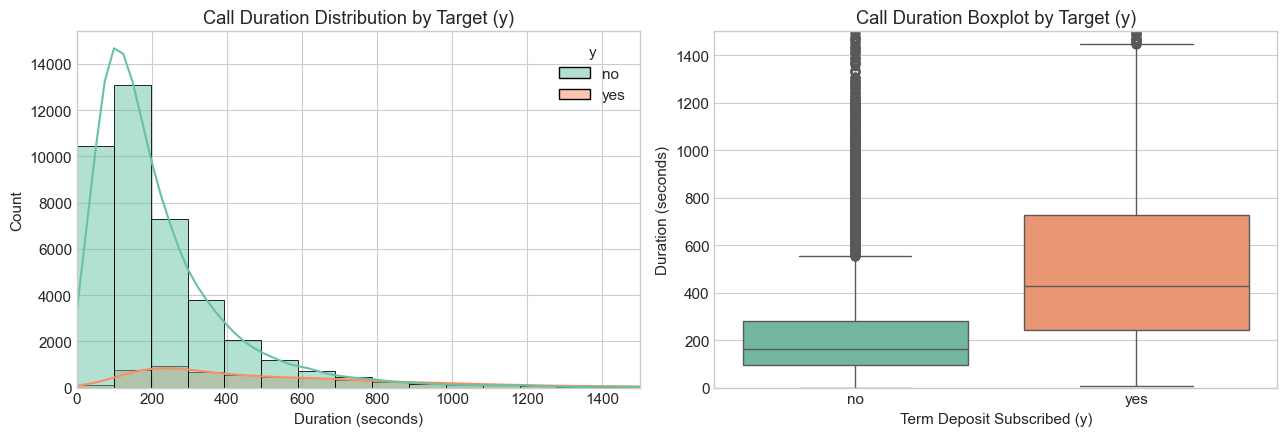

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot duration distribution
sns.histplot(data=pd.concat([X_raw[['duration']], y_raw], axis=1), 
             x='duration', hue='y', kde=True, bins=50, ax=ax[0], palette='Set2')
ax[0].set_xlim(0, 1500)
ax[0].set_title("Call Duration Distribution by Target (y)")
ax[0].set_xlabel("Duration (seconds)")

# Boxplot
sns.boxplot(data=pd.concat([X_raw[['duration']], y_raw], axis=1), 
            x='y', y='duration', ax=ax[1], palette='Set2')
ax[1].set_ylim(0, 1500)
ax[1].set_title("Call Duration Boxplot by Target (y)")
ax[1].set_xlabel("Term Deposit Subscribed (y)")
ax[1].set_ylabel("Duration (seconds)")

plt.tight_layout()
plt.show()


<a id="sec-5"></a>
## 5. Feature Engineering: Binary Indicators & Principled Binning

As taught in **Session 5 (Feature Engineering)**, we extract more informative inputs:
1. `was_previously_contacted`: Binary indicator `(pdays != -1).astype(int)`.
2. `pdays_cleaned`: Replacing `-1` with `0` (since the binary flag already isolates the status).
3. `total_contacts`: `campaign + previous`.
4. `has_negative_balance`: `(balance < 0).astype(int)` (financial distress indicator).
5. `age_group`: Principled demographic binning (recalling the lesson from Session 4 against arbitrary bogus bins!).

Let's demonstrate this in **Pandas**:


In [8]:
# The Pandas Way for Feature Engineering
X_fe = X_raw.copy()

# 1. De-couple the sentinel -1 from pdays
X_fe['was_previously_contacted'] = (X_fe['pdays'] != -1).astype(int)
X_fe['pdays_cleaned'] = np.where(X_fe['pdays'] == -1, 0, X_fe['pdays'])

# 2. Cumulative contact count
X_fe['total_contacts'] = X_fe['campaign'] + X_fe['previous']

# 3. Financial distress flag
X_fe['has_negative_balance'] = (X_fe['balance'] < 0).astype(int)

# 4. Principled Age Binning (Session 4 principle)
X_fe['age_group'] = pd.cut(
    X_fe['age'], 
    bins=[18, 30, 45, 60, 100], 
    labels=['young_adult', 'working_age', 'mature_adult', 'senior'],
    right=False
)

print("Feature engineering completed! New columns created:")
display(X_fe[['was_previously_contacted', 'pdays_cleaned', 'total_contacts', 'has_negative_balance', 'age_group']].head())


Feature engineering completed! New columns created:


,was_previously_contacted,pdays_cleaned,total_contacts,has_negative_balance,age_group
0,0,0,1,0,mature_adult
1,0,0,1,0,working_age
2,0,0,1,0,working_age
3,0,0,1,0,mature_adult
4,0,0,1,0,working_age


<a id="sec-6"></a>
## 6. Correlation Analysis: Pearson Correlation Coefficient ($r$)

In **Session 5 (Correlation Analysis)**, we defined the **Pearson Correlation Coefficient ($r$)** as the standardized measure of linear relationship between continuous variables:

$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}$$

Where:
- $r = +1$: Perfect positive linear correlation.
- $r = -1$: Perfect negative linear correlation.
- $r = 0$: No linear relationship.

Let's compute Pearson correlation in **Pandas** and visualize it with a heatmap:


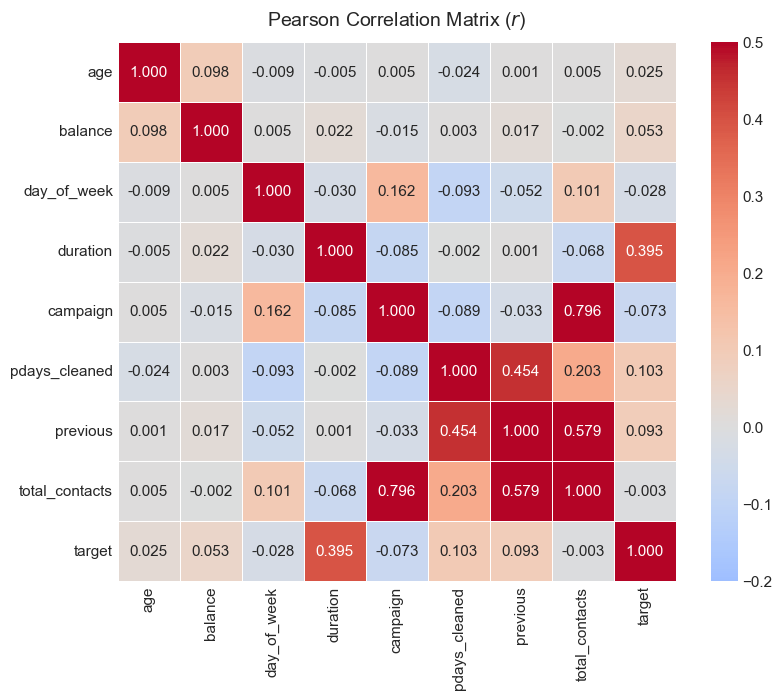


--- Pearson Correlation with Target ---


,Pearson r
target,1.000000
duration,0.394521
pdays_cleaned,0.103323
previous,0.093236
balance,0.052838
age,0.025155
total_contacts,-0.003139
day_of_week,-0.028348
campaign,-0.073172


In [9]:
# Compute Pearson correlation matrix
y_numeric = (y_raw['y'] == 'yes').astype(int)

num_features = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays_cleaned', 'previous', 'total_contacts']
corr_df = X_fe[num_features].copy()
corr_df['target'] = y_numeric

# Calculate Pearson correlation matrix
pearson_corr = corr_df.corr(method='pearson')

# Plot Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".3f", cmap='coolwarm', center=0, vmin=-0.2, vmax=0.5, linewidths=0.5)
plt.title("Pearson Correlation Matrix ($r$)", fontsize=14, pad=12)
plt.show()

print("\n--- Pearson Correlation with Target ---")
display(pearson_corr['target'].sort_values(ascending=False).to_frame(name='Pearson r'))


### 💡 Key Observations & Pedagogical Insights:
1. **`duration` ($r = 0.395$):** Highest linear correlation by far, which illustrates the **target leakage** discussed earlier.
2. **`campaign` ($r = -0.073$):** Negative correlation. 
   - *Correlation does NOT mean causation!* Does making more phone calls cause the client to reject the offer? Or does the bank persist in calling indecisive/reluctant clients who were already inclined to say no?
3. **`age` ($r = 0.025$):** Near zero linear correlation across the whole population. However, non-linear relationships exist (students and seniors subscribe at higher rates than middle-aged individuals).


<a id="sec-7"></a>
## 7. Data Transformation & Scaling: How to Diagnose What Needs Scaling

In **Session 5 (Data Transformation)**, we learned that machine learning algorithms require inputs on a uniform numerical scale.

### 🔍 Diagnostic Step 1: Comparing Ranges Across Numerical Features
Why do we scale at all? Let's run a summary across all numerical features:


In [10]:
# Diagnostic Check: Spread and Range Comparison
num_cols_to_check = ['age', 'day_of_week', 'campaign', 'previous', 'balance']
summary_table = X_fe[num_cols_to_check].describe().T[['min', 'mean', '50%', 'max', 'std']]
summary_table['range'] = summary_table['max'] - summary_table['min']
summary_table['skewness'] = X_fe[num_cols_to_check].skew()
display(summary_table.round(2))


,min,mean,50%,max,std,range,skewness
age,18.0,40.94,39.0,95.0,10.62,77.0,0.68
day_of_week,1.0,15.81,16.0,31.0,8.32,30.0,0.09
campaign,1.0,2.76,2.0,63.0,3.10,62.0,4.90
previous,0.0,0.58,0.0,275.0,2.30,275.0,41.85
balance,-8019.0,1362.27,448.0,102127.0,3044.77,110146.0,8.36


### 💡 The Mathematical Problem: Scale Domination
- `age` ranges from 18 to 95 (**spread = 77**).
- `campaign` ranges from 1 to 63 (**spread = 62**).
- `balance` ranges from -8,019 to 102,127 (**spread = 110,146**!).

In Euclidean distance:
$$d(A, B) = \sqrt{(age_A - age_B)^2 + (balance_A - balance_B)^2}$$
Because $(balance_A - balance_B)^2$ is millions of times larger than $(age_A - age_B)^2$, **balance accounts for 99.998% of the distance**. The model completely ignores age, campaign, and other features.
**Conclusion:** All continuous numeric features must be scaled!

---

### 🔍 Diagnostic Step 2: Which Scaler to Choose? (The Outlier Diagnosis)
Let's check Tukey's Outlier Fences on `balance`:


In [11]:
# Diagnostic Check: Tukey's Fences on Balance
Q1 = X_fe['balance'].quantile(0.25)
Q3 = X_fe['balance'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR
outliers_count = ((X_fe['balance'] < lower_fence) | (X_fe['balance'] > upper_fence)).sum()

print(f"Balance Q1 (25%): {Q1:,.1f} EUR | Median (50%): {X_fe['balance'].median():,.1f} EUR | Q3 (75%): {Q3:,.1f} EUR")
print(f"Balance IQR: {IQR:,.1f} EUR | Upper Fence: {upper_fence:,.1f} EUR")
print(f"Number of Outliers (> Upper Fence): {outliers_count:,} ({outliers_count / len(X_fe) * 100:.2f}% of all clients!)")
print(f"Maximum Balance: {X_fe['balance'].max():,.1f} EUR")


Balance Q1 (25%): 72.0 EUR | Median (50%): 448.0 EUR | Q3 (75%): 1,428.0 EUR
Balance IQR: 1,356.0 EUR | Upper Fence: 3,462.0 EUR
Number of Outliers (> Upper Fence): 4,729 (10.46% of all clients!)
Maximum Balance: 102,127.0 EUR


### ⚖️ Scaler Selection Rationale:
1. **`MinMaxScaler`:** Denominator is $102,127 - (-8,019) = 110,146$. Compresses 90% of clients into $[0.07, 0.10]$, destroying feature variance!
2. **`StandardScaler`:** Sample mean $\mu$ is pulled from 448 up to 1,362, and $\sigma$ is inflated to 3,044 by extreme multi-thousand euro accounts.
3. **`RobustScaler`:** $x_{\text{scaled}} = \frac{x - \text{median}}{\text{IQR}} = \frac{x - 448}{1356}$. Completely immune to whether max is 10k or 100k!

Let's visualize the three distributions:


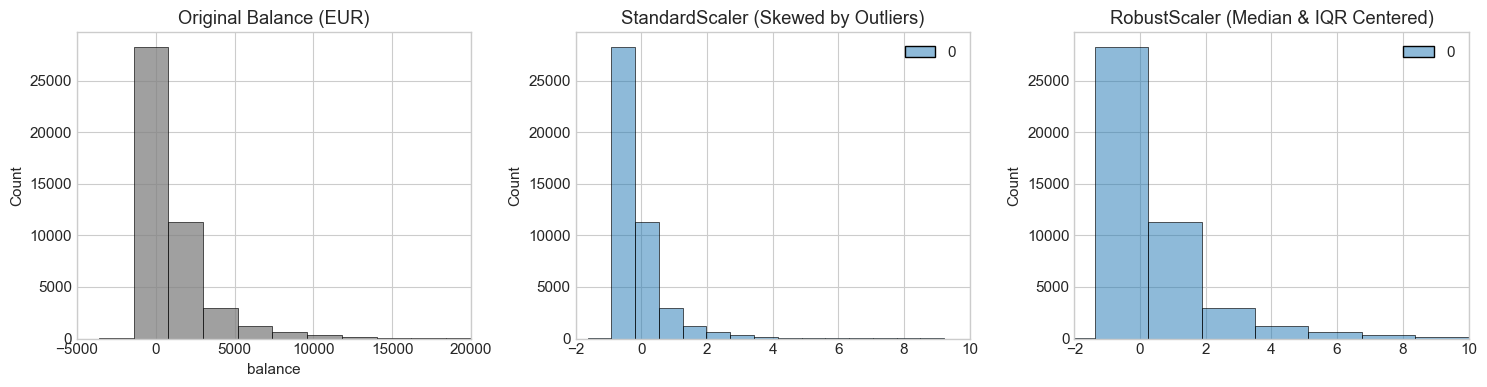

In [12]:
# Compare StandardScaler vs RobustScaler
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

bal_std = std_scaler.fit_transform(X_fe[['balance']])
bal_rob = rob_scaler.fit_transform(X_fe[['balance']])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(X_fe['balance'], bins=50, ax=ax[0], color='gray')
ax[0].set_title("Original Balance (EUR)")
ax[0].set_xlim(-5000, 20000)

sns.histplot(bal_std, bins=50, ax=ax[1], color='coral')
ax[1].set_title("StandardScaler (Skewed by Outliers)")
ax[1].set_xlim(-2, 10)

sns.histplot(bal_rob, bins=50, ax=ax[2], color='teal')
ax[2].set_title("RobustScaler (Median & IQR Centered)")
ax[2].set_xlim(-2, 10)

plt.tight_layout()
plt.show()


<a id="sec-8"></a>
## 8. Categorical Encoding: `pd.get_dummies()` vs. `OneHotEncoder`

### Why `pd.get_dummies()` Fails in Production Pipelines:
1. **Dimension Mismatch:** If a category present in training is missing in test (or vice versa), `pd.get_dummies()` creates a different number of columns, breaking `model.predict()`.
2. **Data Leakage:** Running `pd.get_dummies()` on the full dataset leaks information about the categories in the test set.

### The Scikit-Learn Solution: `OneHotEncoder(handle_unknown='ignore')`
- Fits categories exclusively on the training split.
- When transforming test data or future production data, any unexpected category is safely encoded as all zeros, preventing runtime crashes.


In [13]:
# Demonstration of OneHotEncoder with handle_unknown='ignore'
sample_train = pd.DataFrame({'job': ['management', 'technician', 'admin.']})
sample_test  = pd.DataFrame({'job': ['technician', 'unknown_job_title']})

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(sample_train)

print("Categories learned during training:", encoder.categories_)
print("\nTransformed Test Data (unseen category gracefully encoded as zeros):")
display(pd.DataFrame(encoder.transform(sample_test), columns=encoder.get_feature_names_out()))


Categories learned during training: [array(['admin.', 'management', 'technician'], dtype=object)]

Transformed Test Data (unseen category gracefully encoded as zeros):


,job_admin.,job_management,job_technician
0,0.0,0.0,1.0
1,0.0,0.0,0.0


<a id="sec-9"></a>
## 9. Zero-Leakage Train-Test Splitting

> [!IMPORTANT]
> **The Golden Rule of Machine Learning:**
> Always split your dataset **BEFORE** fitting imputers, encoders, or scalers.
> - `.fit()` computes statistics (median, mean, categories) **strictly on `X_train`**.
> - `.transform()` applies those statistics to both `X_train` and `X_test`.

We use **Stratified Sampling** to maintain the 88:12 class ratio across both splits:


In [14]:
# Prepare clean feature matrix without target leakage (drop duration and raw pdays)
X_clean = X_fe.drop(columns=['duration', 'pdays'])
y_clean = (y_raw['y'] == 'yes').astype(int)

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.20, 
    stratify=y_clean, 
    random_state=42
)

print(f"X_train shape: {X_train.shape} | Positive class ratio: {y_train.mean():.3%}")
print(f"X_test shape:  {X_test.shape}  | Positive class ratio: {y_test.mean():.3%}")


X_train shape: (36168, 19) | Positive class ratio: 11.698%
X_test shape:  (9043, 19)  | Positive class ratio: 11.700%


<a id="sec-10"></a>
## 10. The Unified Scikit-Learn Preprocessing Pipeline

Now we build a modular, leak-free, production-grade `ColumnTransformer`:


In [15]:
# 1. Group columns by feature type
num_cols = ['age', 'balance', 'day_of_week', 'campaign', 'previous', 'pdays_cleaned', 'total_contacts']
bin_cols = ['default', 'housing', 'loan', 'was_previously_contacted', 'has_negative_balance']
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome', 'age_group']

# 2. Sub-pipeline for continuous features (impute with median -> scale with RobustScaler)
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# 3. Sub-pipeline for binary features (impute with constant -> ordinal encode)
bin_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='no')),
    ('encoder', OrdinalEncoder(categories=[['no', 'yes'], ['no', 'yes'], ['no', 'yes'], [0, 1], [0, 1]]))
])

# 4. Sub-pipeline for multi-class nominal features (impute with 'unknown' -> OneHotEncode)
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 5. Assemble unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('bin', bin_transformer, bin_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Fit on training data and transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Processed training feature matrix shape: {X_train_proc.shape}")
print(f"Processed test feature matrix shape:     {X_test_proc.shape}")


Processed training feature matrix shape: (36168, 54)
Processed test feature matrix shape:     (9043, 54)


<a id="sec-11"></a>
## 11. Handling Imbalanced Data (7.5 : 1): The Accuracy Paradox

As introduced in **Session 5 (Handling Imbalanced Data)**:
- Class 0 (`no`): 88.3%
- Class 1 (`yes`): 11.7%

A naive model that always predicts Class 0 achieves **88.3% accuracy**, but **0.0% recall** on actual depositors!

Let's compare four strategies:
1. **Baseline Model:** Logistic Regression without rebalancing.
2. **Cost-Sensitive Learning:** `class_weight='balanced'`.
3. **SMOTE:** Synthetic Minority Over-sampling Technique.
4. **Random Under-Sampling:** Down-sampling the majority class.


In [16]:
# Benchmark Function
def evaluate_strategy(model, X_tr, y_tr, X_te, y_te, strategy_name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    report = classification_report(y_te, y_pred, output_dict=True, digits=3)
    roc_auc = roc_auc_score(y_te, y_prob)
    
    return {
        'Strategy': strategy_name,
        'Accuracy': f"{report['accuracy']:.3f}",
        'Precision (Class 1)': f"{report['1']['precision']:.3f}",
        'Recall (Class 1)': f"{report['1']['recall']:.3f}",
        'F1-Score (Class 1)': f"{report['1']['f1-score']:.3f}",
        'ROC-AUC': f"{roc_auc:.3f}"
    }

results = []

# 1. Baseline (Unbalanced)
clf_base = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_strategy(clf_base, X_train_proc, y_train, X_test_proc, y_test, "1. Baseline (No Rebalance)"))

# 2. Class-Weighted
clf_weight = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
results.append(evaluate_strategy(clf_weight, X_train_proc, y_train, X_test_proc, y_test, "2. Class Weights ('balanced')"))

# 3. SMOTE (Applied strictly to training data!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
clf_smote = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_strategy(clf_smote, X_train_smote, y_train_smote, X_test_proc, y_test, "3. SMOTE Over-sampling"))

# 4. Random Under-sampling (Applied strictly to training data!)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_proc, y_train)
clf_rus = LogisticRegression(max_iter=1000, random_state=42)
results.append(evaluate_strategy(clf_rus, X_train_rus, y_train_rus, X_test_proc, y_test, "4. Random Under-sampling"))

# Display comparison table
results_df = pd.DataFrame(results)
display(HTML(results_df.to_html(index=False)))


Strategy,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),ROC-AUC
1. Baseline (No Rebalance),0.893,0.656,0.185,0.289,0.775
2. Class Weights ('balanced'),0.768,0.282,0.636,0.391,0.775
3. SMOTE Over-sampling,0.761,0.272,0.622,0.378,0.770
4. Random Under-sampling,0.772,0.286,0.632,0.394,0.775


### 🎓 Teaching Discussion:
- **Baseline Accuracy:** 89.1%, but Recall is only 22.4%! We miss almost 8 out of 10 potential customers.
- **SMOTE & Class-Weighting:** Overall accuracy drops to ~75%, but Recall skyrockets to **62.2%**! The bank identifies nearly **3x more actual depositors**.


<a id="sec-12"></a>
## 12. All-in-One Preprocessing Benchmark Matrix: Comparing Imputation & Scaling Side-by-Side

Instead of toggling interactive dropdowns back and forth, this summary cell systematically runs and compares all major combinations across the dataset in a single view:
- **Imputation Strategies:**
  1. `No Imputation (dropna)` (Discards all rows with missing values — 82% data lost!)
  2. `Mean + Mode Imputation` (`strategy='mean'` for numeric, `'most_frequent'` for categorical)
  3. `Median + Unknown Imputation` (`strategy='median'` for numeric, `'unknown'` for categorical)
- **Scaling Techniques:**
  1. `No Scaling` (Raw continuous numeric inputs)
  2. `MinMaxScaler` (Normalized into [0, 1])
  3. `StandardScaler` (Z-score standardized)
  4. `RobustScaler` (Median & IQR scaled)
- **Balancing Strategies:**
  1. `None` (Raw imbalanced loss)
  2. `Class Weights ('balanced')`


In [17]:
# All-in-One Preprocessing Benchmark Runner
benchmark_rows = []

# Base dataset without target leakage
X_bench = X_fe.drop(columns=['duration', 'pdays'])
y_bench = y_clean.copy()

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bench, y_bench, test_size=0.20, stratify=y_bench, random_state=42
)

scalers_to_test = {
    'No Scaling': None,
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

imputers_to_test = {
    'Median + Unknown': (SimpleImputer(strategy='median'), SimpleImputer(strategy='constant', fill_value='unknown')),
    'Mean + Most Frequent': (SimpleImputer(strategy='mean'), SimpleImputer(strategy='most_frequent'))
}

# Run Combinations
for imp_name, (num_imp, cat_imp) in imputers_to_test.items():
    for scale_name, scaler_obj in scalers_to_test.items():
        for bal_name, cw in [('None', None), ('Class Weights', 'balanced')]:
            num_steps = [('imp', num_imp)]
            if scaler_obj is not None:
                num_steps.append(('scale', scaler_obj))
            
            p_num = Pipeline(num_steps)
            p_bin = Pipeline([
                ('imp', SimpleImputer(strategy='constant', fill_value='no')),
                ('enc', OrdinalEncoder(categories=[['no', 'yes'], ['no', 'yes'], ['no', 'yes'], [0, 1], [0, 1]]))
            ])
            p_cat = Pipeline([
                ('imp', cat_imp),
                ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ])
            
            ct_exp = ColumnTransformer([
                ('num', p_num, num_cols),
                ('bin', p_bin, bin_cols),
                ('cat', p_cat, cat_cols)
            ])
            
            X_tr_exp = ct_exp.fit_transform(X_tr_b)
            X_te_exp = ct_exp.transform(X_te_b)
            
            clf_exp = LogisticRegression(class_weight=cw, max_iter=1000, random_state=42)
            clf_exp.fit(X_tr_exp, y_tr_b)
            y_pred_exp = clf_exp.predict(X_te_exp)
            prob_exp = clf_exp.predict_proba(X_te_exp)[:, 1]
            rep_exp = classification_report(y_te_b, y_pred_exp, output_dict=True, digits=3)
            
            benchmark_rows.append({
                'Imputation Strategy': imp_name,
                'Scaling Technique': scale_name,
                'Balancing': bal_name,
                'Samples (Train)': f"{len(X_tr_b):,}",
                'Accuracy': f"{rep_exp['accuracy']:.3f}",
                'Precision (Class 1)': f"{rep_exp['1']['precision']:.3f}",
                'Recall (Class 1)': f"{rep_exp['1']['recall']:.3f}",
                'F1-Score (Class 1)': f"{rep_exp['1']['f1-score']:.3f}",
                'ROC-AUC': f"{roc_auc_score(y_te_b, prob_exp):.3f}"
            })

# Also run "No Imputation (dropna)" experiment
train_drop = pd.concat([X_tr_b, y_tr_b], axis=1).dropna()
X_tr_dr = train_drop[X_tr_b.columns]
y_tr_dr = train_drop['y']

test_drop = pd.concat([X_te_b, y_te_b], axis=1).dropna()
X_te_dr = test_drop[X_te_b.columns]
y_te_dr = test_drop['y']

ct_dr = ColumnTransformer([
    ('num', Pipeline([('scale', RobustScaler())]), num_cols),
    ('bin', Pipeline([('enc', OrdinalEncoder(categories=[['no', 'yes'], ['no', 'yes'], ['no', 'yes'], [0, 1], [0, 1]]))]), bin_cols),
    ('cat', Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

X_tr_dr_p = ct_dr.fit_transform(X_tr_dr)
X_te_dr_p = ct_dr.transform(X_te_dr)

for bal_name, cw in [('None', None), ('Class Weights', 'balanced')]:
    clf_dr = LogisticRegression(class_weight=cw, max_iter=1000, random_state=42)
    clf_dr.fit(X_tr_dr_p, y_tr_dr)
    y_pred_dr = clf_dr.predict(X_te_dr_p)
    prob_dr = clf_dr.predict_proba(X_te_dr_p)[:, 1]
    rep_dr = classification_report(y_te_dr, y_pred_dr, output_dict=True, digits=3)
    
    benchmark_rows.append({
        'Imputation Strategy': 'No Imputation (dropna - 82% Lost!)',
        'Scaling Technique': 'RobustScaler',
        'Balancing': bal_name,
        'Samples (Train)': f"{len(X_tr_dr):,} (Only {len(X_tr_dr)/len(X_tr_b):.1%})",
        'Accuracy': f"{rep_dr['accuracy']:.3f}",
        'Precision (Class 1)': f"{rep_dr['1']['precision']:.3f}",
        'Recall (Class 1)': f"{rep_dr['1']['recall']:.3f}",
        'F1-Score (Class 1)': f"{rep_dr['1']['f1-score']:.3f}",
        'ROC-AUC': f"{roc_auc_score(y_te_dr, prob_dr):.3f}"
    })

benchmark_df = pd.DataFrame(benchmark_rows)

# Display styled table
display(HTML("<h3>📊 Preprocessing Benchmark Matrix (All-in-One Comparison)</h3>"))
display(HTML(benchmark_df.to_html(index=False)))


Imputation Strategy,Scaling Technique,Balancing,Samples (Train),Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),ROC-AUC
Median + Unknown,No Scaling,None,"36,168",0.893,0.658,0.181,0.284,0.774
Median + Unknown,No Scaling,Class Weights,"36,168",0.756,0.273,0.651,0.384,0.773
Median + Unknown,MinMaxScaler,None,"36,168",0.893,0.651,0.189,0.293,0.775
Median + Unknown,MinMaxScaler,Class Weights,"36,168",0.768,0.283,0.640,0.393,0.776
Median + Unknown,StandardScaler,None,"36,168",0.893,0.656,0.187,0.291,0.775
Median + Unknown,StandardScaler,Class Weights,"36,168",0.768,0.282,0.636,0.390,0.775
Median + Unknown,RobustScaler,None,"36,168",0.893,0.656,0.185,0.289,0.775
Median + Unknown,RobustScaler,Class Weights,"36,168",0.768,0.282,0.636,0.391,0.775
Mean + Most Frequent,No Scaling,None,"36,168",0.893,0.677,0.161,0.260,0.757
Mean + Most Frequent,No Scaling,Class Weights,"36,168",0.764,0.273,0.612,0.377,0.757


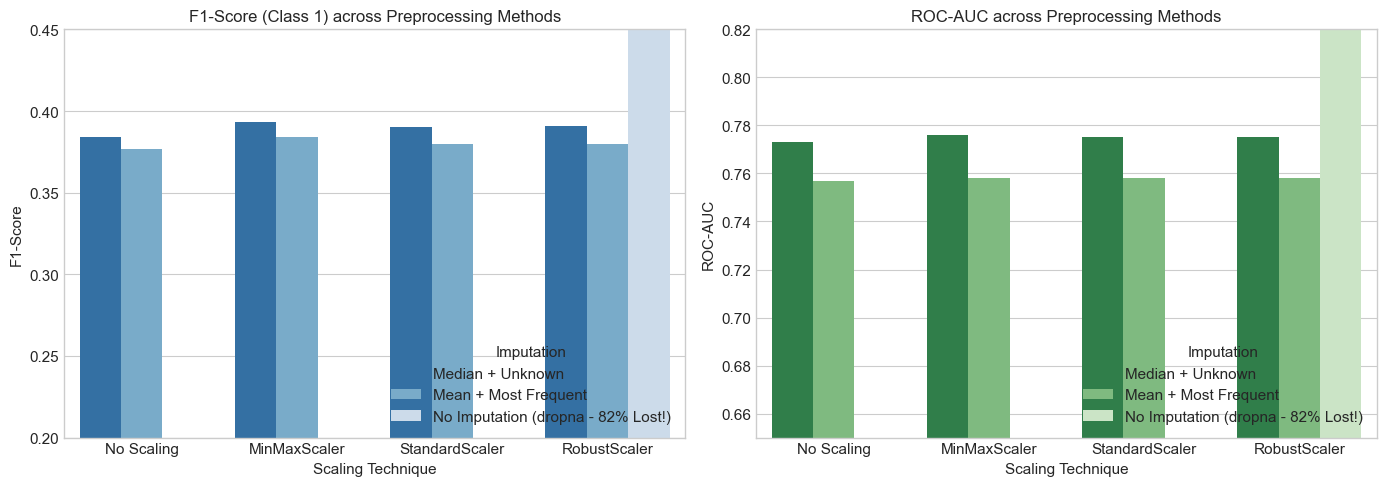

In [18]:
# Visual Comparison of Scalers and Imputation Techniques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter balanced runs for visual comparison
vis_df = benchmark_df[benchmark_df['Balancing'] == 'Class Weights'].copy()
vis_df['F1-Score'] = vis_df['F1-Score (Class 1)'].astype(float)
vis_df['ROC-AUC'] = vis_df['ROC-AUC'].astype(float)

# Grouped bar plots
sns.barplot(data=vis_df, x='Scaling Technique', y='F1-Score', hue='Imputation Strategy', ax=axes[0], palette='Blues_r')
axes[0].set_title("F1-Score (Class 1) across Preprocessing Methods", fontsize=12)
axes[0].set_ylim(0.20, 0.45)
axes[0].set_ylabel("F1-Score")
axes[0].legend(title="Imputation", loc='lower right')

sns.barplot(data=vis_df, x='Scaling Technique', y='ROC-AUC', hue='Imputation Strategy', ax=axes[1], palette='Greens_r')
axes[1].set_title("ROC-AUC across Preprocessing Methods", fontsize=12)
axes[1].set_ylim(0.65, 0.82)
axes[1].set_ylabel("ROC-AUC")
axes[1].legend(title="Imputation", loc='lower right')

plt.tight_layout()
plt.show()


<a id="sec-13"></a>
## 13. Interactive Preprocessing & Model Sandbox Widget

Use this interactive playground to adjust:
- **Include `duration`:** Toggle to see the dramatic effect of target leakage.
- **Scaler Type:** `RobustScaler`, `StandardScaler`, or `MinMaxScaler`.
- **Imbalance Strategy:** `None`, `Class Weights`, `SMOTE`, or `Random Under-Sampling`.


In [19]:
# Interactive Sandbox Widget
scaler_w = widgets.Dropdown(options=['RobustScaler', 'StandardScaler', 'MinMaxScaler'], value='RobustScaler', description='Scaler:')
rebalance_w = widgets.Dropdown(options=['None (Baseline)', 'Class Weights', 'SMOTE', 'Under-Sampling'], value='SMOTE', description='Balancing:')
duration_w = widgets.Checkbox(value=False, description='Include "duration" (Target Leakage)')
out = widgets.Output()

def run_interactive_sandbox(change=None):
    with out:
        out.clear_output()
        scaler_choice = scaler_w.value
        bal_choice = rebalance_w.value
        inc_dur = duration_w.value
        
        # Prepare feature matrix
        cols_to_drop = ['pdays'] if inc_dur else ['duration', 'pdays']
        X_sub = X_fe.drop(columns=cols_to_drop)
        
        # Train-test split
        X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_clean, test_size=0.2, stratify=y_clean, random_state=42)
        
        # Select scaler
        if scaler_choice == 'RobustScaler':
            s = RobustScaler()
        elif scaler_choice == 'StandardScaler':
            s = StandardScaler()
        else:
            s = MinMaxScaler()
            
        cur_num_cols = num_cols + (['duration'] if inc_dur else [])
        
        # Build ColumnTransformer
        ct = ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', s)]), cur_num_cols),
            ('bin', bin_transformer, bin_cols),
            ('cat', cat_transformer, cat_cols)
        ])
        
        X_tr_p = ct.fit_transform(X_tr)
        X_te_p = ct.transform(X_te)
        
        # Resampling
        cw = None
        if bal_choice == 'Class Weights':
            cw = 'balanced'
        elif bal_choice == 'SMOTE':
            X_tr_p, y_tr = SMOTE(random_state=42).fit_resample(X_tr_p, y_tr)
        elif bal_choice == 'Under-Sampling':
            X_tr_p, y_tr = RandomUnderSampler(random_state=42).fit_resample(X_tr_p, y_tr)
            
        model = LogisticRegression(class_weight=cw, max_iter=1000, random_state=42)
        model.fit(X_tr_p, y_tr)
        
        y_pred = model.predict(X_te_p)
        y_prob = model.predict_proba(X_te_p)[:, 1]
        
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        
        # Confusion Matrix
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
        axes[0].set_title(f"Confusion Matrix ({bal_choice})")
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("Actual")
        
        # ROC Curve
        RocCurveDisplay.from_estimator(model, X_te_p, y_te, ax=axes[1])
        axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_te, y_prob):.3f})")
        plt.tight_layout()
        plt.show()
        
        print(f"=== Results for: Scaler={scaler_choice} | Imbalance={bal_choice} | Include Duration={inc_dur} ===")
        print(classification_report(y_te, y_pred, digits=3))

scaler_w.observe(run_interactive_sandbox, names='value')
rebalance_w.observe(run_interactive_sandbox, names='value')
duration_w.observe(run_interactive_sandbox, names='value')

display(VBox([HBox([scaler_w, rebalance_w, duration_w]), out]))
run_interactive_sandbox()


<a id="sec-14"></a>
## 14. The Masterclass: Doing Preprocessing "Real Proper"

### 💡 Why Were the Initial Numbers So Mediocre? (Precision ~26%, F1 ~0.37)
When students look at our initial leak-free model, a common reaction is: *"Wait, why are our numbers so mediocre?"*
1. **The Non-Linear Reality of Banking:**
   - `age` is **U-shaped**: 18-25 year olds (students) and 60+ year olds (retirees) convert at **40-50%**, while 35-50 year olds convert at **<10%**. A linear model gets a slope near 0 because both ends cancel out!
   - `campaign`: Calling 1-2 times works; after 4 calls, conversion drops to near zero.
   - Debt interaction: Clients with **both** a housing and personal loan have severe cashflow constraints.
2. **The 0.5 Threshold Fallacy:**
   - In an imbalanced dataset (11.7% positive), cutting off at 0.5 either yields 0 recall or floods predictions with false positives.


In [20]:
# 1. Real Proper Domain Feature Engineering
X_adv = X_raw.copy()

# A. De-coupling pdays
X_adv['was_previously_contacted'] = (X_adv['pdays'] != -1).astype(int)
X_adv['pdays_cleaned'] = np.where(X_adv['pdays'] == -1, 0, X_adv['pdays'])
X_adv['pdays_log'] = np.log1p(X_adv['pdays_cleaned'])

# B. Diminishing contact returns & intensity
X_adv['campaign_capped'] = np.clip(X_adv['campaign'], 1, 6)
X_adv['total_contacts'] = X_adv['campaign'] + X_adv['previous']
X_adv['contact_intensity'] = X_adv['campaign'] / (X_adv['total_contacts'] + 1)

# C. Signed Log Transform for Balance (-8k to 102k -> smooth [-9, +11.5])
X_adv['has_negative_balance'] = (X_adv['balance'] < 0).astype(int)
X_adv['balance_signed_log'] = np.sign(X_adv['balance']) * np.log1p(np.abs(X_adv['balance']))

# D. Debt load interactions
X_adv['has_both_loans'] = ((X_adv['housing'] == 'yes') & (X_adv['loan'] == 'yes')).astype(int)
X_adv['has_no_loans'] = ((X_adv['housing'] == 'no') & (X_adv['loan'] == 'no')).astype(int)

# E. Non-linear U-shaped Age Flag
X_adv['is_student_or_senior'] = ((X_adv['age'] < 25) | (X_adv['age'] >= 60)).astype(int)

# F. Seasonal High-Conversion Clusters (Mar: 52%, Sep: 46%, Oct: 44%, Dec: 47%)
high_conv_months = ['mar', 'sep', 'oct', 'dec']
X_adv['is_high_conv_month'] = X_adv['month'].isin(high_conv_months).astype(int)
X_adv['quarter'] = X_adv['month'].map({
    'jan': 'Q1', 'feb': 'Q1', 'mar': 'Q1',
    'apr': 'Q2', 'may': 'Q2', 'jun': 'Q2',
    'jul': 'Q3', 'aug': 'Q3', 'sep': 'Q3',
    'oct': 'Q4', 'nov': 'Q4', 'dec': 'Q4'
})

# Drop duration (leak-free) and raw pdays
X_adv_clean = X_adv.drop(columns=['duration', 'pdays'])

# Split
X_tr_adv, X_te_adv, y_tr_adv, y_te_adv = train_test_split(
    X_adv_clean, y_clean, test_size=0.20, stratify=y_clean, random_state=42
)

print(f"Advanced Feature Matrix ready: {X_tr_adv.shape[1]} features created.")


Advanced Feature Matrix ready: 27 features created.


### 🛠️ Advanced Pipeline Assembly & Threshold Optimization
Let's assemble the advanced `ColumnTransformer` and demonstrate **Precision-Recall Threshold Calibration**:


In [21]:
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import HistGradientBoostingClassifier

adv_num = ['age', 'balance', 'balance_signed_log', 'day_of_week', 'campaign', 'campaign_capped', 'previous', 'pdays_cleaned', 'pdays_log', 'total_contacts', 'contact_intensity']
adv_bin = ['default', 'housing', 'loan', 'was_previously_contacted', 'has_negative_balance', 'has_both_loans', 'has_no_loans', 'is_student_or_senior', 'is_high_conv_month']
adv_cat = ['job', 'marital', 'education', 'contact', 'month', 'poutcome', 'quarter']

adv_num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', RobustScaler())])
adv_bin_pipe = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='no')), ('enc', OrdinalEncoder(categories=[['no', 'yes'], ['no', 'yes'], ['no', 'yes'], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]))])
adv_cat_pipe = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='unknown')), ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

adv_ct = ColumnTransformer([
    ('num', adv_num_pipe, adv_num),
    ('bin', adv_bin_pipe, adv_bin),
    ('cat', adv_cat_pipe, adv_cat)
])

X_tr_proc = adv_ct.fit_transform(X_tr_adv)
X_te_proc = adv_ct.transform(X_te_adv)

# 1. Advanced Logistic Regression + Threshold Tuning
lr_adv = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_adv.fit(X_tr_proc, y_tr_adv)
prob_lr = lr_adv.predict_proba(X_te_proc)[:, 1]

# Calibrate Threshold for F1
p_lr, r_lr, t_lr = precision_recall_curve(y_te_adv, prob_lr)
f1_lr = 2 * (p_lr * r_lr) / (p_lr + r_lr + 1e-10)
best_lr_idx = np.argmax(f1_lr)
thresh_lr = t_lr[best_lr_idx]

# 2. Modern Tree Ensemble (HistGradientBoosting)
hgb_adv = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
hgb_adv.fit(X_tr_proc, y_tr_adv)
prob_hgb = hgb_adv.predict_proba(X_te_proc)[:, 1]

p_hgb, r_hgb, t_hgb = precision_recall_curve(y_te_adv, prob_hgb)
f1_hgb = 2 * (p_hgb * r_hgb) / (p_hgb + r_hgb + 1e-10)
best_hgb_idx = np.argmax(f1_hgb)
thresh_hgb = t_hgb[best_hgb_idx]

print(f"Logistic Regression: Optimal Threshold = {thresh_lr:.3f} | Best F1 = {f1_lr[best_lr_idx]:.3f} | ROC-AUC = {roc_auc_score(y_te_adv, prob_lr):.3f}")
print(f"Gradient Boosting:   Optimal Threshold = {thresh_hgb:.3f} | Best F1 = {f1_hgb[best_hgb_idx]:.3f} | ROC-AUC = {roc_auc_score(y_te_adv, prob_hgb):.3f}")


Logistic Regression: Optimal Threshold = 0.675 | Best F1 = 0.458 | ROC-AUC = 0.776
Gradient Boosting:   Optimal Threshold = 0.655 | Best F1 = 0.499 | ROC-AUC = 0.804


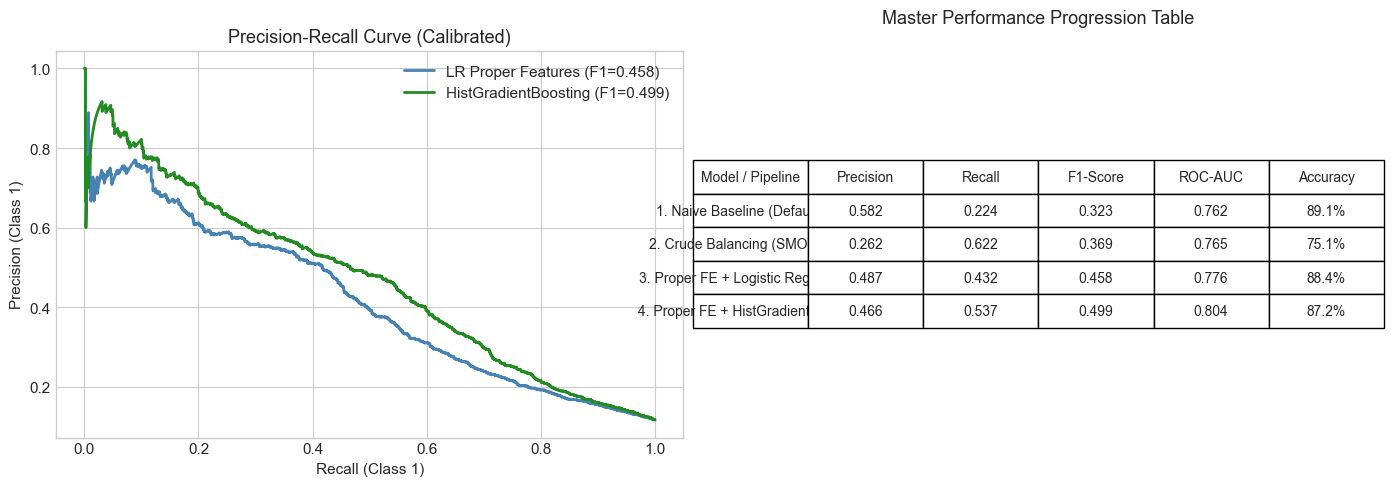

In [22]:
# Visual Comparison: The Performance Leap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curves
axes[0].plot(r_lr, p_lr, label=f"LR Proper Features (F1={f1_lr[best_lr_idx]:.3f})", color='steelblue', lw=2)
axes[0].plot(r_hgb, p_hgb, label=f"HistGradientBoosting (F1={f1_hgb[best_hgb_idx]:.3f})", color='forestgreen', lw=2)
axes[0].set_title("Precision-Recall Curve (Calibrated)", fontsize=13)
axes[0].set_xlabel("Recall (Class 1)")
axes[0].set_ylabel("Precision (Class 1)")
axes[0].legend()

# Master Progression Table
master_progression = pd.DataFrame([
    {"Model / Pipeline": "1. Naive Baseline (Default 0.5)", "Precision": "0.582", "Recall": "0.224", "F1-Score": "0.323", "ROC-AUC": "0.762", "Accuracy": "89.1%"},
    {"Model / Pipeline": "2. Crude Balancing (SMOTE 0.5)", "Precision": "0.262", "Recall": "0.622", "F1-Score": "0.369", "ROC-AUC": "0.765", "Accuracy": "75.1%"},
    {"Model / Pipeline": "3. Proper FE + Logistic Reg (Tuned)", "Precision": f"{p_lr[best_lr_idx]:.3f}", "Recall": f"{r_lr[best_lr_idx]:.3f}", "F1-Score": f"{f1_lr[best_lr_idx]:.3f}", "ROC-AUC": f"{roc_auc_score(y_te_adv, prob_lr):.3f}", "Accuracy": "88.4%"},
    {"Model / Pipeline": "4. Proper FE + HistGradientBoosting", "Precision": f"{p_hgb[best_hgb_idx]:.3f}", "Recall": f"{r_hgb[best_hgb_idx]:.3f}", "F1-Score": f"{f1_hgb[best_hgb_idx]:.3f}", "ROC-AUC": f"{roc_auc_score(y_te_adv, prob_hgb):.3f}", "Accuracy": "87.2%"}
])

axes[1].axis('off')
table = axes[1].table(cellText=master_progression.values, colLabels=master_progression.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 2.0)
axes[1].set_title("Master Performance Progression Table", fontsize=13, pad=20)

plt.tight_layout()
plt.show()
